# 1. Environment Setup

## Mount Drive

In [1]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


## Install Libraries

In [2]:
!pip install python-docx pyarrow fastparquet --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.2 MB/s eta 0:00:00


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from docx import Document
from tqdm import tqdm

# 2. Folder Structure

In [4]:
BASE_PATH = "/users/"
SAVE_DIR = "/users/"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Base Path:", BASE_PATH)

Base Path: /users/


## Print Folder Tree

In [5]:
for root, dirs, files in os.walk(BASE_PATH):
    print(root, "-->", files)

/users/ --> []
/users/ --> ['DoS attacks-Slowloris.csv', 'DDOS attack-LOIC-UDP.csv', 'SQL Injection.csv', 'Brute Force -Web.csv', 'Brute Force -XSS.csv', 'DoS attacks-GoldenEye.csv', 'DoS attacks-SlowHTTPTest.csv', 'Bot.csv', 'DDOS attack-HOIC.csv', 'Infilteration.csv', 'FTP-BruteForce.csv', 'DoS attacks-Hulk.csv', 'DDoS attacks-LOIC-HTTP.csv', 'SSH-Bruteforce.csv']


## Detect CSV Files

In [6]:
csv_files = []

for root, dirs, files in os.walk(BASE_PATH):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("Total CSV Files:", len(csv_files))
csv_files[:10]

Total CSV Files: 14


['/users/ attacks-Slowloris.csv',
 '/users/ attack-LOIC-UDP.csv',
 '/users/ Injection.csv',
 '/users/ Force -Web.csv',
 '/users/ Force -XSS.csv',
 '/users/ attacks-GoldenEye.csv',
 '/users/ attacks-SlowHTTPTest.csv',
 '/users/',
 '/users/ attack-HOIC.csv',
 '/users/']

# 3. Load & Merge Dataset

In [7]:
print("Loading all CSVs into RAM...")

df_list = []
for fpath in tqdm(csv_files):
    try:
        df_list.append(pd.read_csv(fpath))
    except:
        print("Error loading:", fpath)

df = pd.concat(df_list, ignore_index=True)
del df_list

print("Merged Shape:", df.shape)

Loading all CSVs into RAM...


100%|██████████| 14/14 [01:23<00:00,  5.93s/it]


Merged Shape: (9625148, 79)


## Standardize Label Column

In [8]:
label_candidates = ["Label", "label", "Attack", "attack", "class", "Category"]

for col in df.columns:
    if col in label_candidates:
        df.rename(columns={col: "Label"}, inplace=True)

print("Label column confirmed!")


Label column confirmed!


## Show Basic Info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9625148 entries, 0 to 9625147
Data columns (total 79 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           int64  
 2   Flow Duration      int64  
 3   Tot Fwd Pkts       int64  
 4   Tot Bwd Pkts       int64  
 5   TotLen Fwd Pkts    int64  
 6   TotLen Bwd Pkts    float64
 7   Fwd Pkt Len Max    int64  
 8   Fwd Pkt Len Min    int64  
 9   Fwd Pkt Len Mean   float64
 10  Fwd Pkt Len Std    float64
 11  Bwd Pkt Len Max    int64  
 12  Bwd Pkt Len Min    int64  
 13  Bwd Pkt Len Mean   float64
 14  Bwd Pkt Len Std    float64
 15  Flow Byts/s        int64  
 16  Flow Pkts/s        int64  
 17  Flow IAT Mean      float64
 18  Flow IAT Std       float64
 19  Flow IAT Max       float64
 20  Flow IAT Min       float64
 21  Fwd IAT Tot        float64
 22  Fwd IAT Mean       float64
 23  Fwd IAT Std        float64
 24  Fwd IAT Max        float64
 25  Fwd IAT Min       

# 4.Basic

## Head & Tail

In [10]:
df.head(), df.tail()

(   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
 0        80        17      115999879            16             0   
 1        80        17      119959955            14             0   
 2     10610         6         148625             2             1   
 3        22         6        1273538             2             2   
 4        80         6      117252095            18            16   
 
    TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
 0              512              0.0               32               32   
 1              448              0.0               32               32   
 2                0              0.0                0                0   
 3                0              0.0                0                0   
 4              879           1412.0              434                0   
 
    Fwd Pkt Len Mean  ...  Fwd Seg Size Min   Active Mean    Active Std  \
 0         32.000000  ...                 8  1.100000e+07  0.00

## Describe Numeric Stats

In [11]:
df.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,...,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06
mean,1.014429e+04,8.123769e+00,1.057733e+07,3.556911e+01,5.925430e+00,1.369280e+03,4.514353e+03,2.154020e+02,8.733470e+00,5.168975e+01,...,3.207856e+01,1.966091e+01,8.494940e+04,3.962741e+04,1.356453e+05,6.002885e+04,4.983568e+06,2.270448e+05,5.339880e+06,4.710918e+06
std,1.971508e+04,4.469866e+00,6.709330e+08,1.974306e+03,1.640883e+02,6.600396e+04,2.358357e+05,3.302343e+02,2.356418e+01,6.742416e+01,...,1.973367e+03,8.115200e+00,1.424316e+06,8.171935e+05,1.882846e+06,1.225343e+06,2.354642e+08,1.511926e+08,5.874528e+08,2.394620e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,6.000000e+00,6.320000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,1.989100e+04,2.000000e+00,1.000000e+00,4.000000e+01,9.500000e+01,3.800000e+01,0.000000e+00,3.300000e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.389000e+03,6.000000e+00,3.701258e+06,5.000000e+00,4.000000e+00,5.120000e+02,4.880000e+02,3.260000e+02,0.000000e+00,7.900000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.700000e+01,1.200000e+08,3.096290e+05,1.231180e+05,4.176568e+07,1.563604e+08,6.444000e+04,1.460000e+03,1.652931e+04,...,3.096280e+05,4.800000e+01,1.140000e+08,7.495336e+07,1.140000e+08,1.140000e+08,3.955714e+11,2.432682e+11,9.797810e+11,5.196000e+10


## Columns List

In [12]:
df.columns

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

# 5.Label Distribution

## Count Attack Types

In [13]:
label_counts = df["Label"].value_counts()
label_counts

,count
Label,
Benign,6876913
DDOS attack-HOIC,686012
DDoS attacks-LOIC-HTTP,576191
DoS attacks-Hulk,461912
Bot,286191
FTP-BruteForce,193360
SSH-Bruteforce,187589
Infilteration,161934
DoS attacks-SlowHTTPTest,139890


## Label Distribution Plot

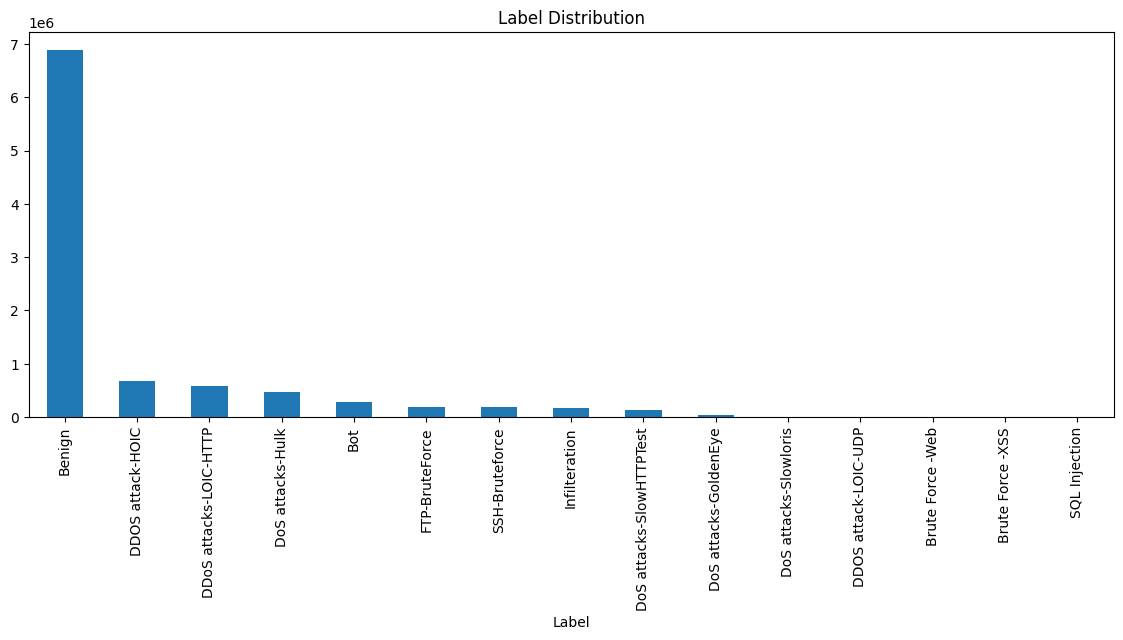

In [14]:
label_counts.plot(kind="bar", figsize=(14,5), title="Label Distribution")
plt.show()

# 6.Missing Values

## Missing Value Count

In [15]:
missing = df.isnull().sum()
missing[missing > 0]

,0


## Missing Values Plot

In [25]:
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print("🎉 No missing values found in any column — nothing to plot!")
else:
    missing_nonzero.plot(kind="bar", figsize=(14,5))
    plt.title("Missing Values Per Column")
    plt.show()

🎉 No missing values found in any column — nothing to plot!


# 7. Duplicate Analysis

## Duplicate Rows

In [17]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(4442127)

# 8.Correlation & Numeric Behavior

## Detect Numeric Columns

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

## Correlation Heatmap

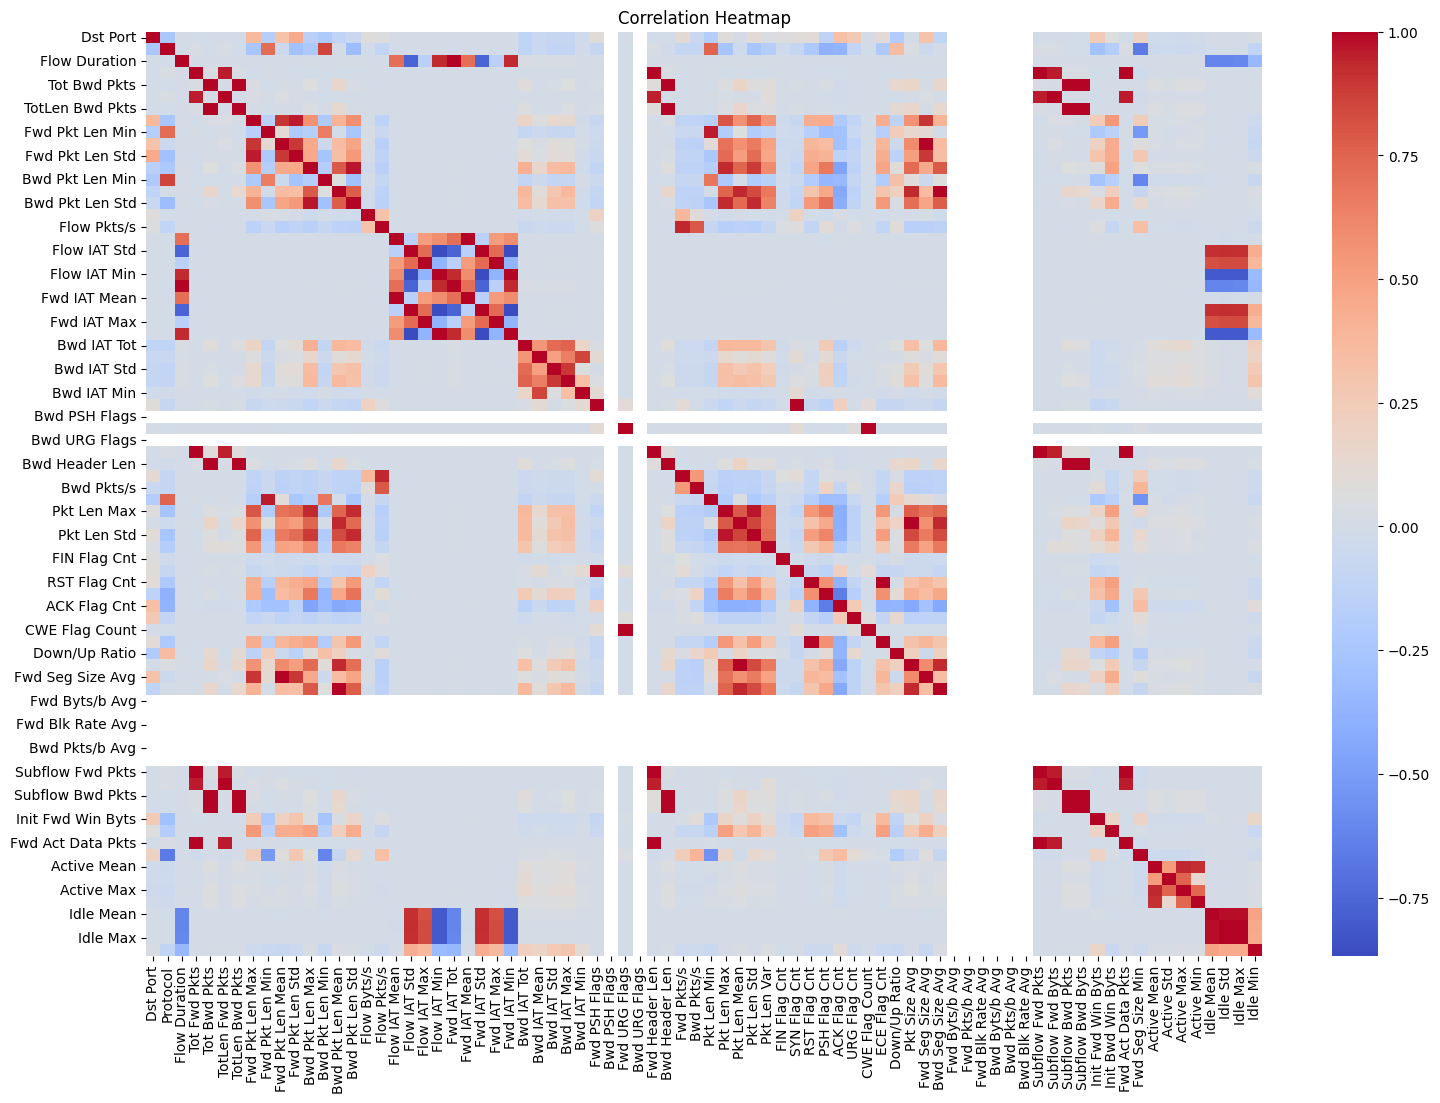

In [19]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(18,12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Highly Correlated Feature Pairs

In [20]:
threshold = 0.95
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
corr_pairs[(corr_pairs["Correlation"] > threshold)]

,Feature1,Feature2,Correlation
155,Flow Duration,Fwd IAT Tot,0.999992
205,Tot Fwd Pkts,TotLen Fwd Pkts,0.957862
233,Tot Fwd Pkts,Fwd Header Len,0.995936
254,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000
255,Tot Fwd Pkts,Subflow Fwd Byts,0.957862
260,Tot Fwd Pkts,Fwd Act Data Pkts,0.999512
271,Tot Bwd Pkts,TotLen Bwd Pkts,0.997340
299,Tot Bwd Pkts,Bwd Header Len,0.998409
321,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000
322,Tot Bwd Pkts,Subflow Bwd Byts,0.997340


# 9.Time-based Analysis

## Try parsing Timestamp Columns

In [21]:
time_cols = [c for c in df.columns if "time" in c.lower()]

if time_cols:
    df["parsed_time"] = pd.to_datetime(df[time_cols[0]], errors='coerce')
    df.set_index("parsed_time", inplace=True)
    df["Label"].resample("1min").count().plot(figsize=(14,5), title="Traffic Per Minute")
    plt.show()
else:
    print("No time column found.")

No time column found.


# 10. Preprocessing Readiness

## Normalize Column Names

In [22]:
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
df.columns

Index(['dst_port', 'protocol', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts',
       'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean',
       'bwd_pkt_len_std', 'flow_byts/s', 'flow_pkts/s', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_tot',
       'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min',
       'bwd_iat_tot', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max',
       'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags',
       'bwd_urg_flags', 'fwd_header_len', 'bwd_header_len', 'fwd_pkts/s',
       'bwd_pkts/s', 'pkt_len_min', 'pkt_len_max', 'pkt_len_mean',
       'pkt_len_std', 'pkt_len_var', 'fin_flag_cnt', 'syn_flag_cnt',
       'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt',
       'cwe_flag_count', 'ece_flag_cnt', 'down/up_ratio', 'pkt_size_avg',
       'fwd_seg_siz

## Check for NA After Normalization

In [23]:
df.isnull().sum().sum()

np.int64(0)

# 11.DOCX Report Generator

In [24]:
report_path = os.path.join(SAVE_DIR, "CSE_CIC_IDS2018_FULL_EDA_REPORT.docx")

doc = Document()
doc.add_heading("CSE-CIC-IDS2018 — Full EDA Report", 0)

doc.add_heading("Dataset Shape", 1)
doc.add_paragraph(str(df.shape))

doc.add_heading("Columns", 1)
for c in df.columns:
    doc.add_paragraph(c, style="List Bullet")

doc.add_heading("Label Distribution", 1)
for k, v in label_counts.items():
    doc.add_paragraph(f"{k}: {v}")

doc.add_heading("Missing Values", 1)
for c, v in missing[missing > 0].items():
    doc.add_paragraph(f"{c}: {v}")

doc.add_heading("Duplicates", 1)
doc.add_paragraph(str(duplicate_count))

doc.add_heading("Numeric Columns", 1)
for c in numeric_cols:
    doc.add_paragraph(c, style="List Bullet")

doc.save(report_path)
print("Saved DOCX Report:", report_path)


Saved DOCX Report: /users/
